##**This notebook demos Python data visualization on the Iris dataset**
#Some commonly used graphics and some rarely used ones :)


importing libraries

In [78]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [79]:
data = pd.read_csv('/content/Iris.csv')

In [5]:
data.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
data.shape

(150, 6)

In [10]:
data.describe().round(2)

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.00,150.00,150.00,150.00,150.00
mean,75.50,5.84,3.05,3.76,1.20
std,43.45,0.83,0.43,1.76,0.76
min,1.00,4.30,2.00,1.00,0.10
25%,38.25,5.10,2.80,1.60,0.30
50%,75.50,5.80,3.00,4.35,1.30
75%,112.75,6.40,3.30,5.10,1.80
max,150.00,7.90,4.40,6.90,2.50


In [11]:
data.Species.value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


scatter plot between x and y

<Axes: xlabel='SepalLengthCm', ylabel='SepalWidthCm'>

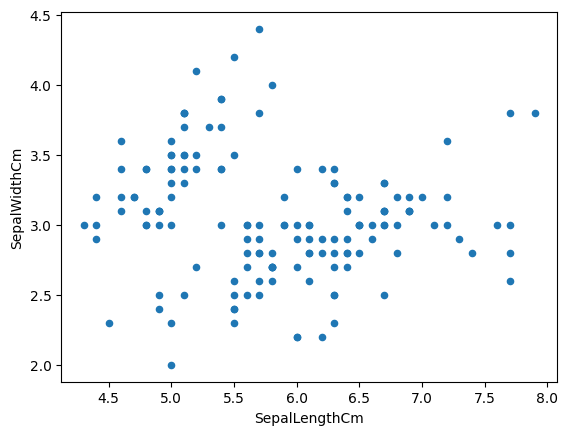

In [13]:
data.plot(kind = 'scatter', x = 'SepalLengthCm', y = 'SepalWidthCm')

<Axes: xlabel='PetalLengthCm', ylabel='PetalWidthCm'>

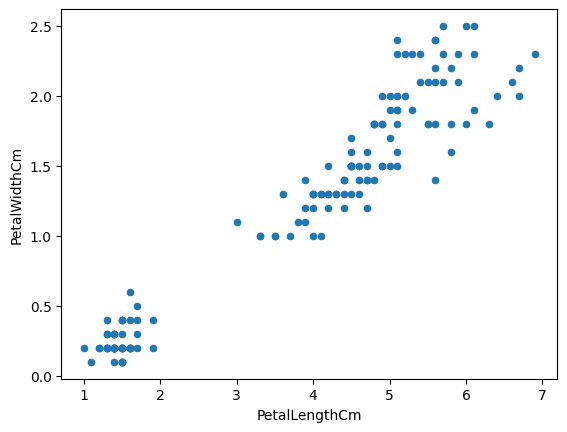

In [14]:
data.plot(kind = 'scatter', x = 'PetalLengthCm', y = 'PetalWidthCm')

joint plot (sns) between x and y (gives extra info)

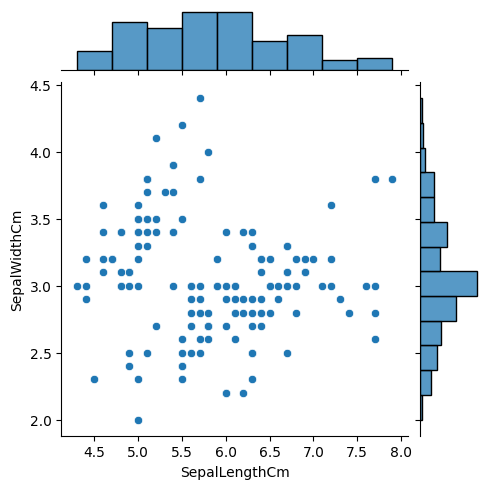

In [22]:
sns.jointplot(x = 'SepalLengthCm', y = 'SepalWidthCm', data = data, height=5)

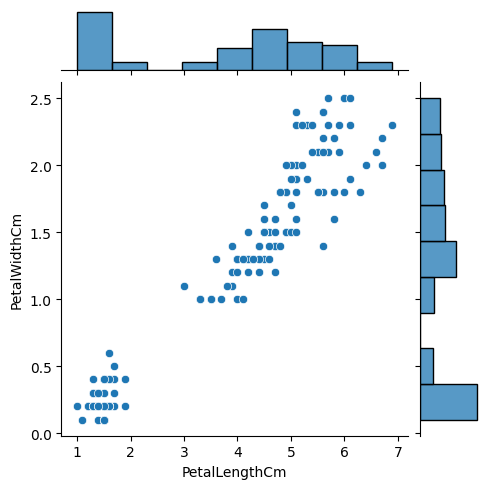

In [27]:
sns.jointplot(x = 'PetalLengthCm', y = 'PetalWidthCm', data = data, height=5)

joint plot (sns) differentiated by hues for species

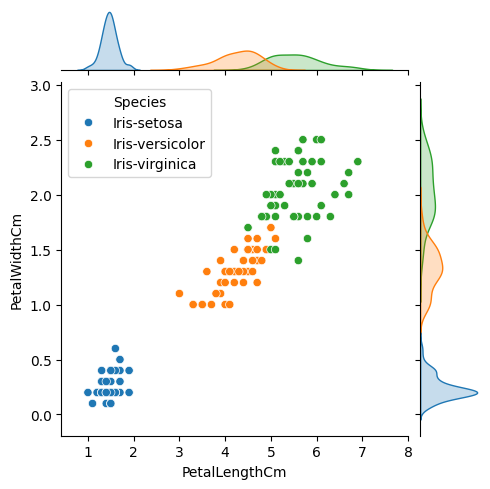

In [28]:
sns.jointplot(x = 'PetalLengthCm', y = 'PetalWidthCm', data = data, height=5, hue= 'Species')

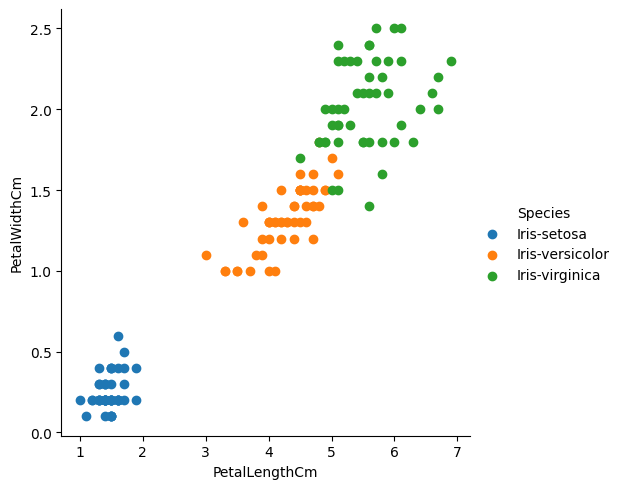

In [31]:
sns.FacetGrid(data, hue="Species", height=5).map(plt.scatter, "PetalLengthCm", "PetalWidthCm").add_legend()

box plot for species

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

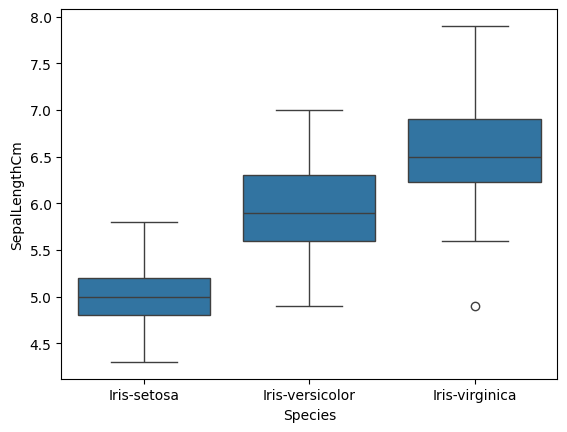

In [33]:
sns.boxplot(x = 'Species', y = 'SepalLengthCm', data = data)

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

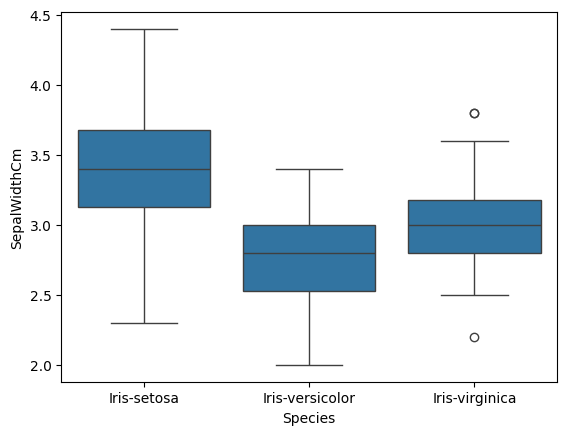

In [34]:
sns.boxplot(x = 'Species', y = 'SepalWidthCm', data = data)

box and strip plot (sns) for each specie, tells variation for each group

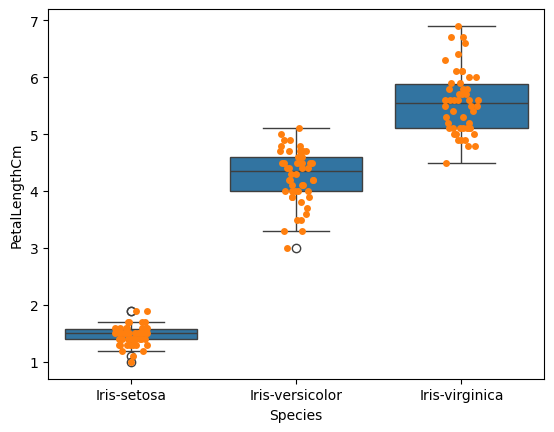

In [42]:
ax = sns.boxplot(x="Species", y="PetalLengthCm", data=data)
ax = sns.stripplot(x="Species", y="PetalLengthCm", data=data, jitter=True, edgecolor="gray")

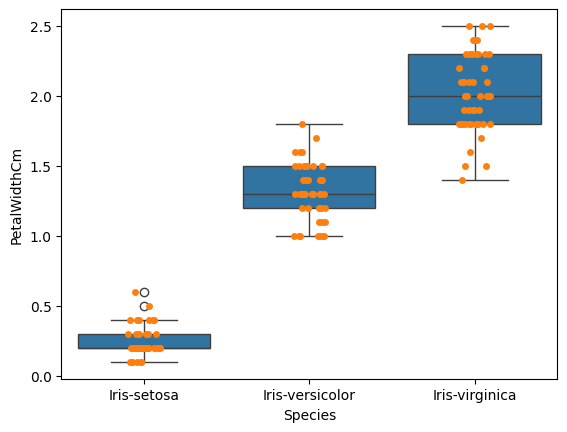

In [43]:
ax = sns.boxplot(x="Species", y="PetalWidthCm", data=data)
ax = sns.stripplot(x="Species", y="PetalWidthCm", data=data, jitter=True, edgecolor="gray")

violin plot (sns) for each specie , more dense = more data distribution

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

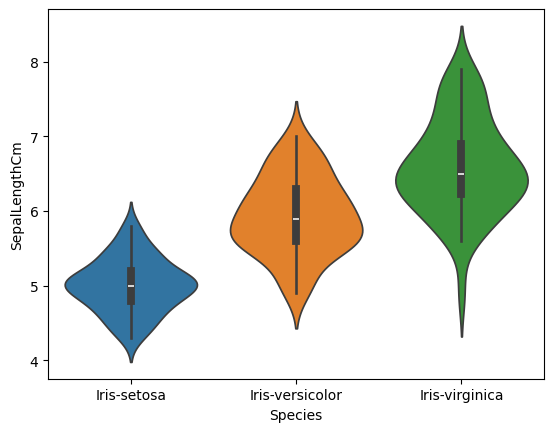

In [49]:
sns.violinplot(x = 'Species', y = 'SepalLengthCm', data = data, hue= 'Species')

<Axes: xlabel='Species', ylabel='SepalWidthCm'>

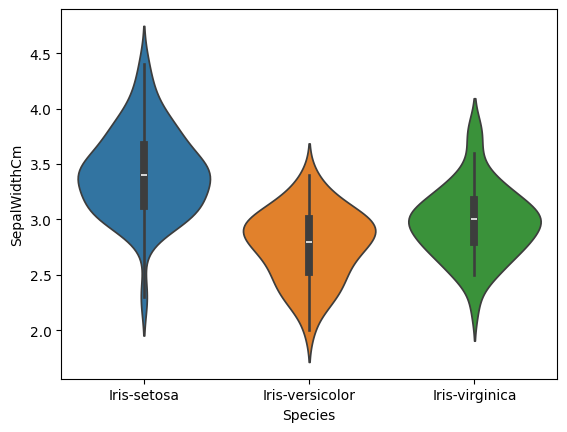

In [50]:
sns.violinplot(x = 'Species', y = 'SepalWidthCm', data = data, hue= 'Species')

kde (sns) plot

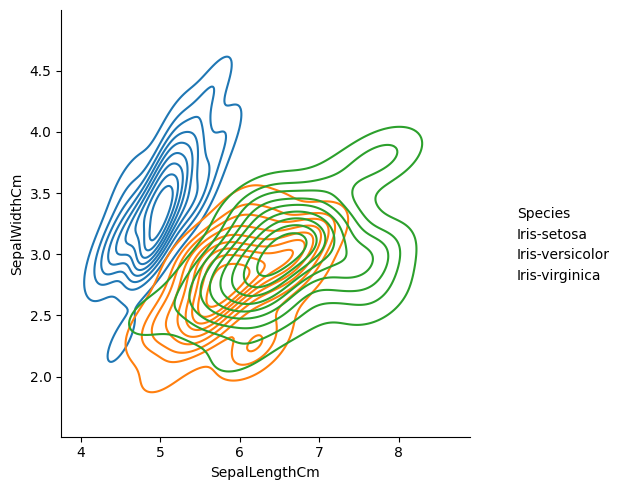

In [51]:
sns.FacetGrid(data, hue="Species", height=5).map(sns.kdeplot, "SepalLengthCm", "SepalWidthCm").add_legend()

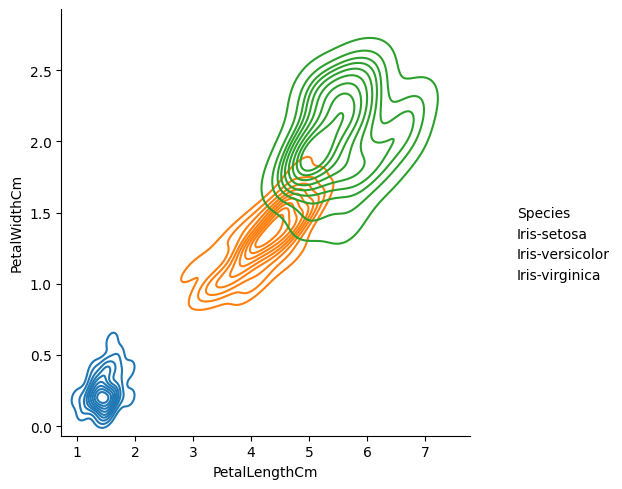

In [52]:
sns.FacetGrid(data, hue="Species", height=5).map(sns.kdeplot, "PetalLengthCm", "PetalWidthCm").add_legend()

pair plot (sns) dropping id column using axis = 1

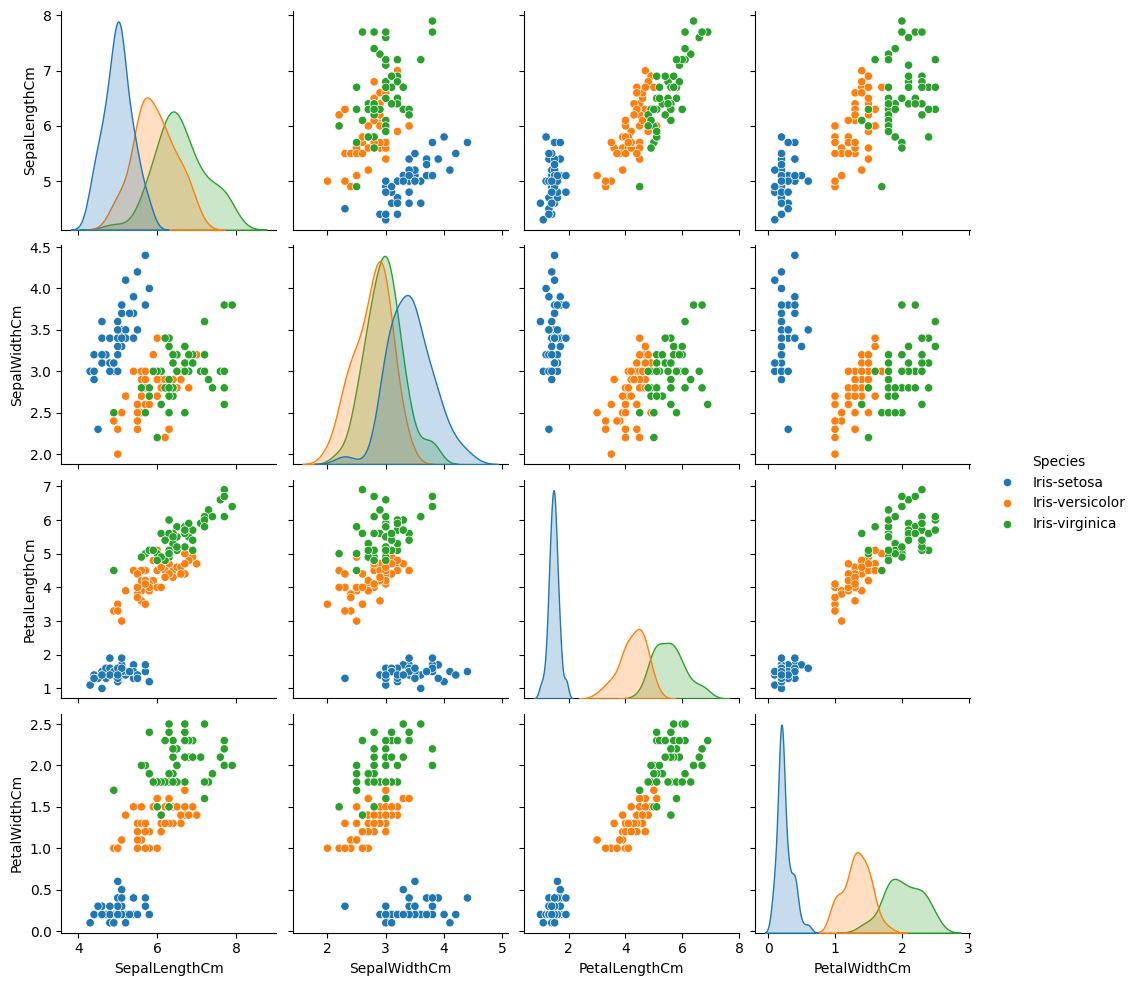

In [55]:
sns.pairplot(data.drop("Id", axis = 1), hue = 'Species')

boxplot for each specie

array([[<Axes: title={'center': 'PetalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'PetalWidthCm'}, xlabel='[Species]'>],
       [<Axes: title={'center': 'SepalLengthCm'}, xlabel='[Species]'>,
        <Axes: title={'center': 'SepalWidthCm'}, xlabel='[Species]'>]],
      dtype=object)

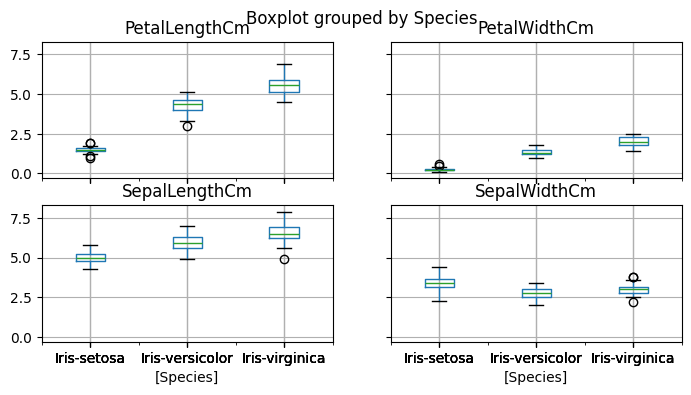

In [63]:
data.drop("Id", axis=1).boxplot(by = 'Species', figsize = (8, 4))

andrew curve (pandas.plotting)

<Axes: >

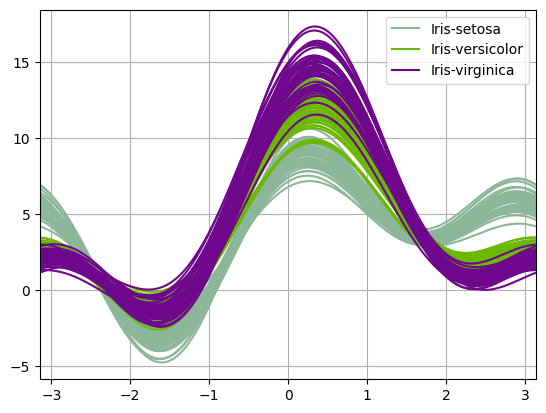

In [65]:
from pandas.plotting import andrews_curves
andrews_curves(data.drop("Id", axis=1), "Species")

parallel corrdinates (pandas)

<Axes: >

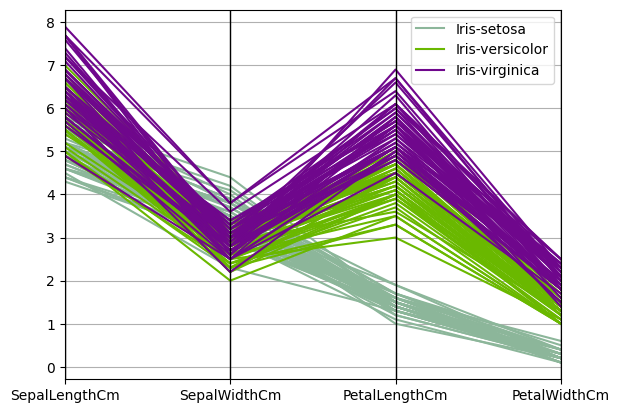

In [66]:
from pandas.plotting import parallel_coordinates
parallel_coordinates(data.drop("Id", axis=1), "Species")

radviz (pandas)

<Axes: >

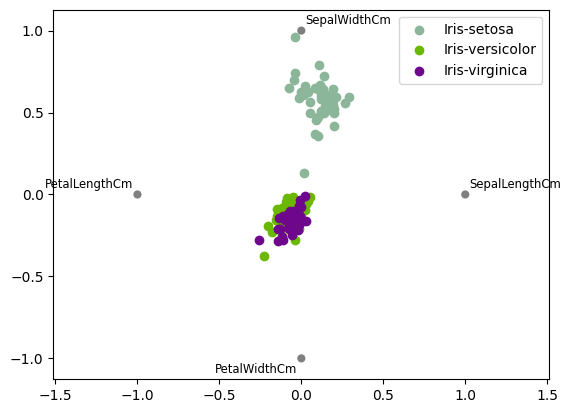

In [67]:
from pandas.plotting import radviz
radviz(data.drop("Id", axis=1), "Species")

checking missing value using missing no library (bar and matrix)

<Axes: >

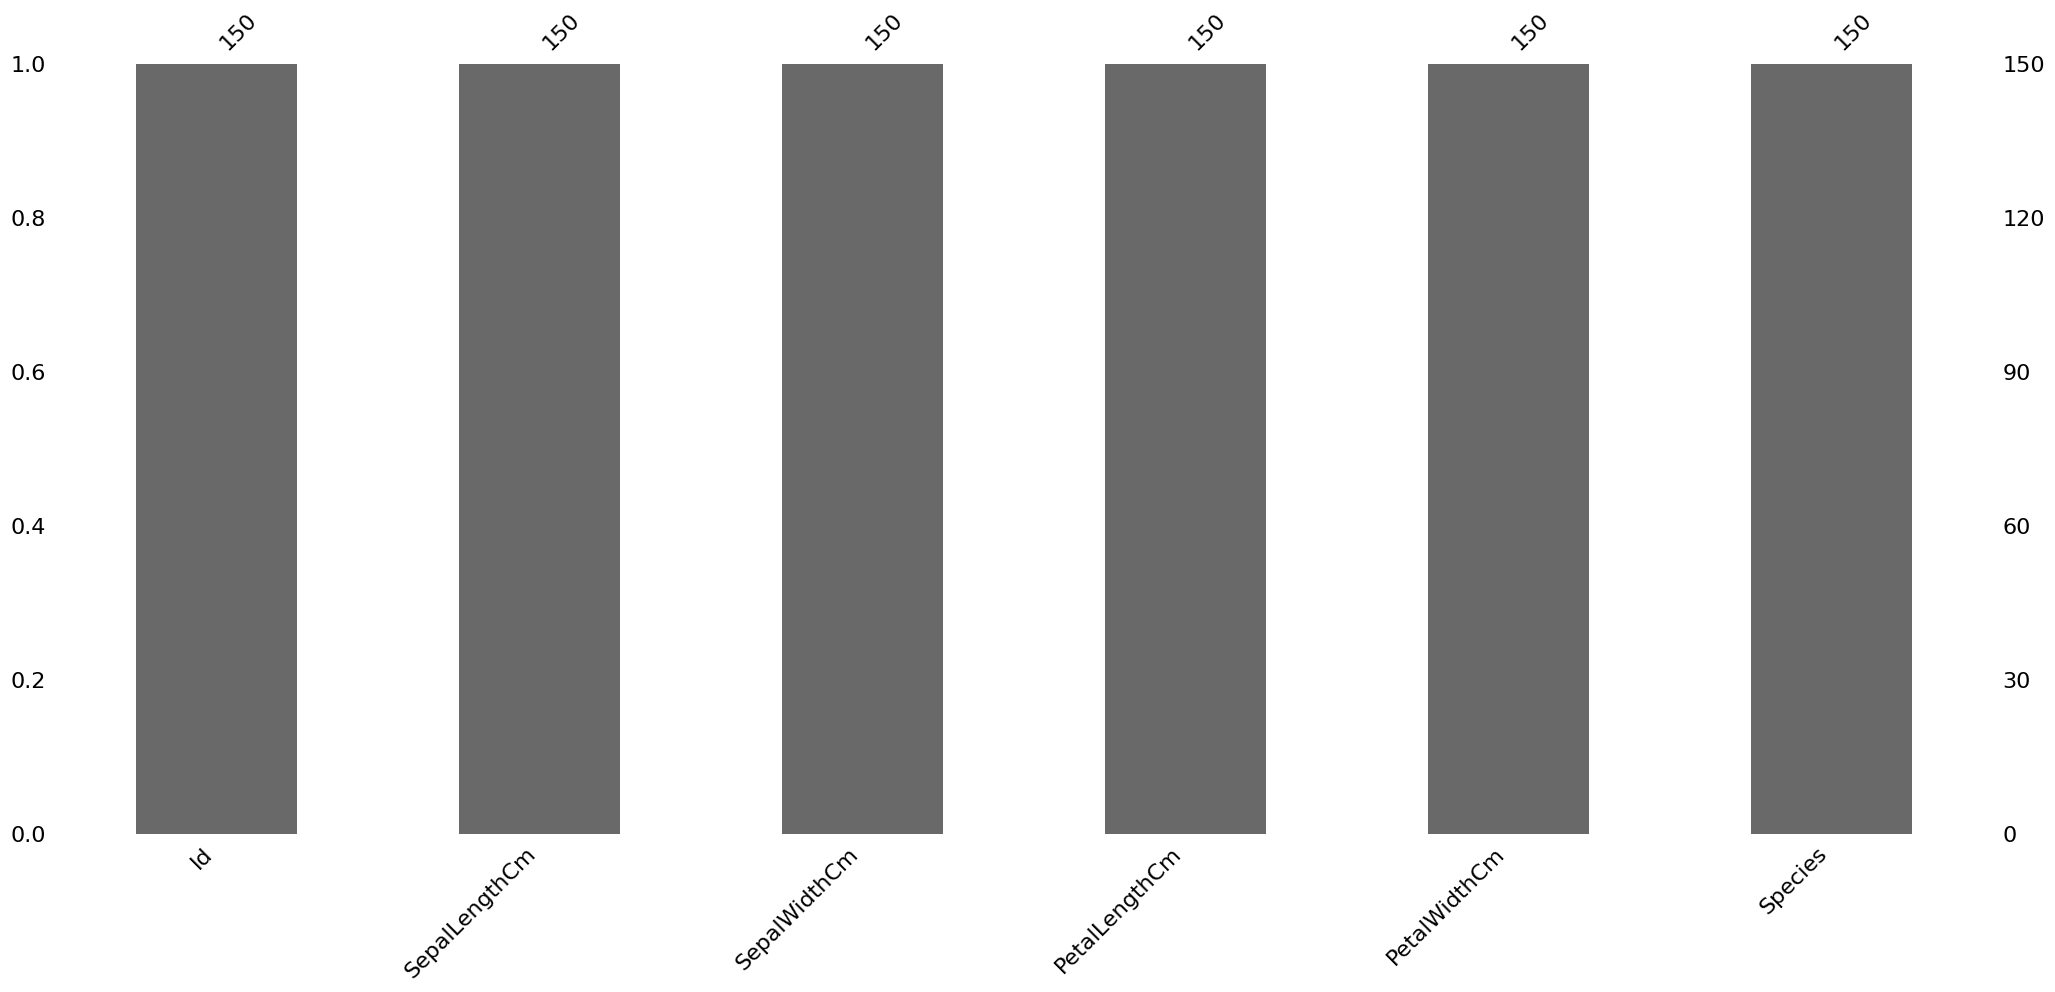

In [68]:
# plot to check missing values using missingno fxn
import missingno as msno
msno.bar(data)

<Axes: >

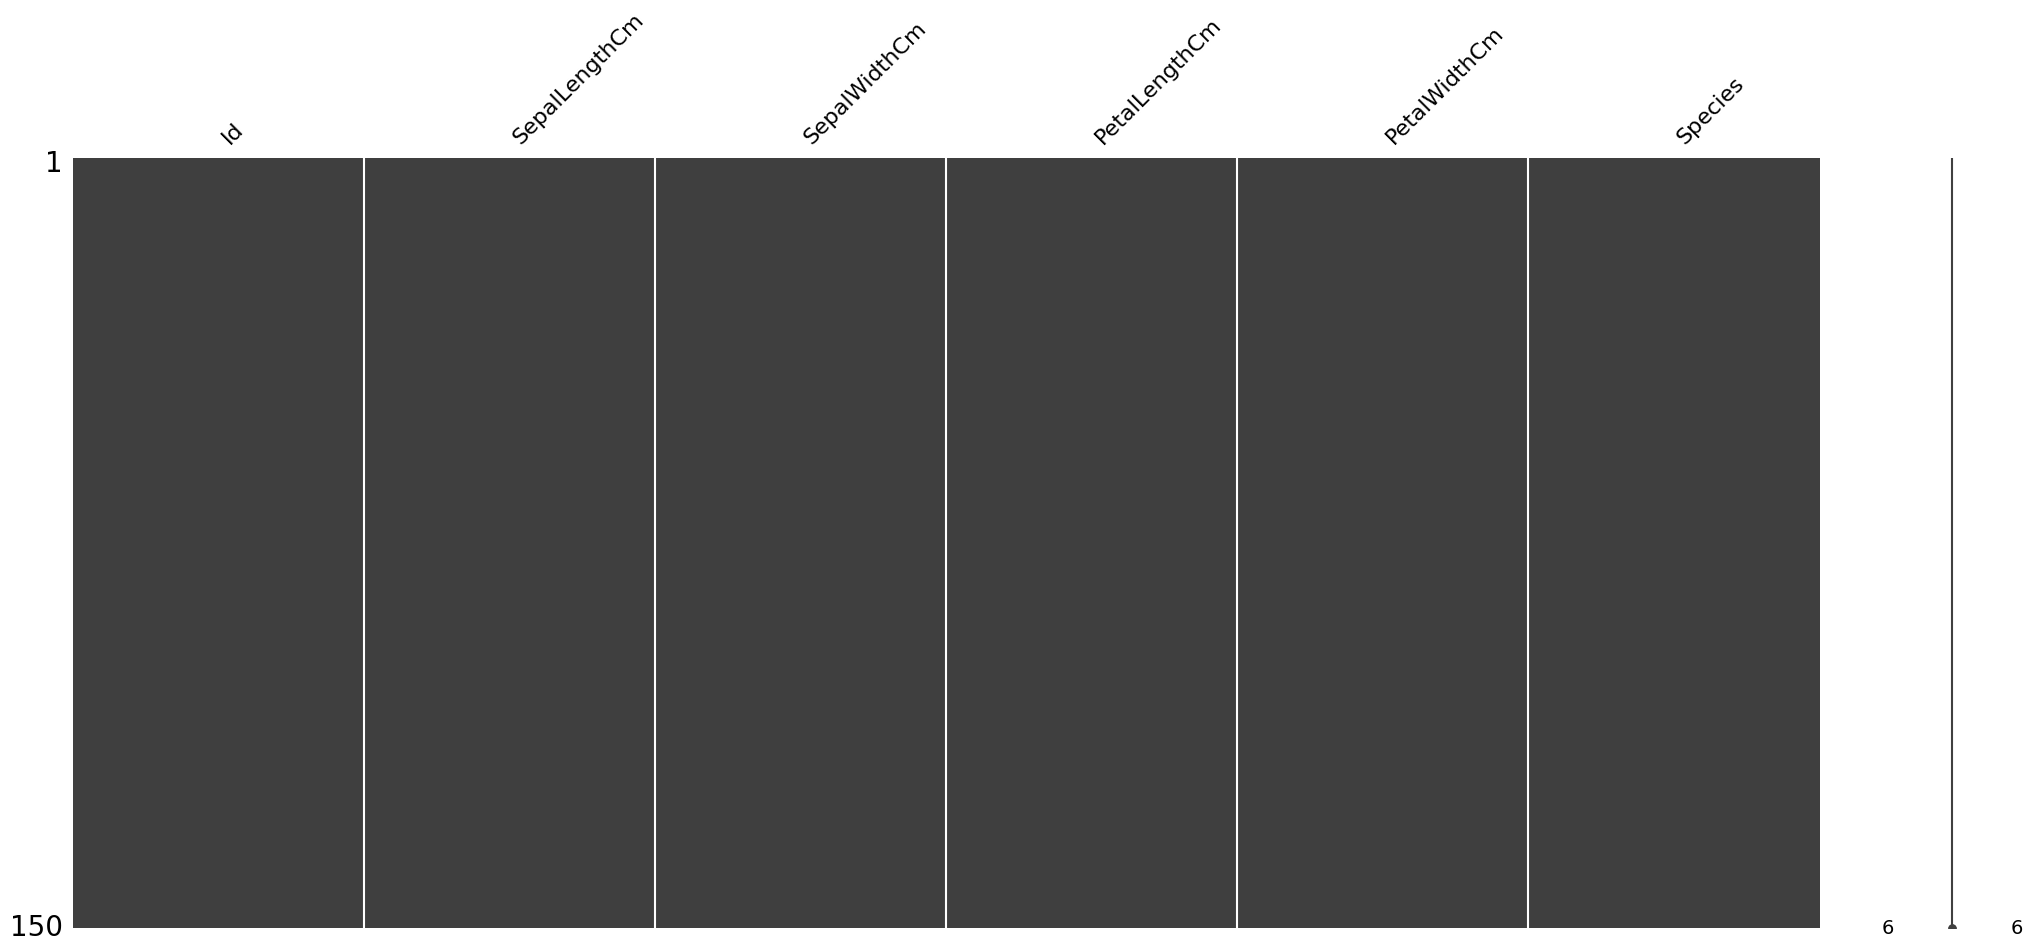

In [69]:
msno.matrix(data)

calculating correlation matrix

In [76]:
corr = data.iloc[:,1:5].corr()
corr

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
SepalLengthCm,1.000000,-0.109369,0.871754,0.817954
SepalWidthCm,-0.109369,1.000000,-0.420516,-0.356544
PetalLengthCm,0.871754,-0.420516,1.000000,0.962757
PetalWidthCm,0.817954,-0.356544,0.962757,1.000000


heatmap using corr

<Axes: >

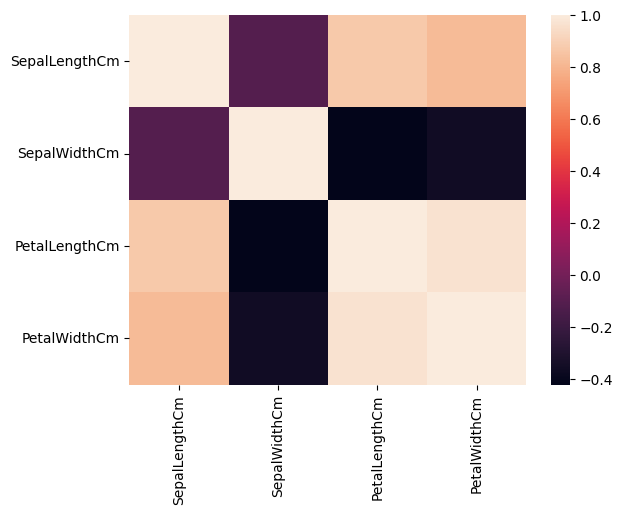

In [77]:
sns.heatmap(corr)